# EDA Codealong

## Data ingestion and Preliminary DA

In [59]:
# importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import scipy as stats
from zipfile import ZipFile


In [60]:
# let load the data from the zipfile
path=r"C:\Users\OLASQUARE\Downloads\Compressed\wine+quality.zip"

with ZipFile(path, 'r') as zip_ref:
    zip_ref.printdir()

File Name                                             Modified             Size
winequality-red.csv                            2023-05-22 22:24:00        84199
winequality-white.csv                          2023-05-22 22:24:00       264426
winequality.names                              2023-05-22 22:24:00         3305


In [61]:
# loading only winequality-white.csv
with ZipFile(path) as zip_ref:
    with zip_ref.open("winequality-white.csv") as f:
        white_wine= pd.read_csv(f, sep=";")

In [62]:
# snap shot of the data
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [63]:
white_wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [64]:
# let pick numeric colums
numeric_cols= white_wine.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [65]:
white_wine[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


In [66]:
# let check the column dtype
white_wine.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [67]:
white_wine.quality.unique()

array([6, 5, 7, 8, 4, 3, 9], dtype=int64)

| Numeric | Category   | Meaning               |
| ------- | ---------- | --------------------- |
| 3–4     | **Low**    | Poor quality wines    |
| 5–6     | **Medium** | Average/typical wines |
| 7–8+    | **High**   | Premium-quality wines |


In [68]:
# let define a function to map the quality to categories

def map_quality_category(quality):
    if quality<=4:
        return "Low"
    elif quality<=6:
        return "Medium"
    else:
        return "High"
    
# make use of the function
white_wine['quality_value']= white_wine['quality'].apply(map_quality_category)
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_value
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,Medium
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,Medium
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,Medium
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,Medium
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,Medium


In [69]:
# make a copy of the data
df=white_wine.copy()

# EDA started here

## 1. Univariate analysis
Analysing one column/features at a time

What to look out for when carrying out univariate analysis:

1. Distribution -Normal, poisson, binomial, Bernoulli distributions
2. How they are organized around the centre - measure of central tendency(mean, median and mode)
3. How they are dispersed from the centre - measure of dispersion(standard deviation, variance, kurtosis, skewness)
4. The type of plots that can be used include  **histogram**,**boxplots**, **countplot**.

The idea behind univariate analysis is To understand each variable individually, its distribution, central tendency, spread, shape, and presence of outliers..

### Univariate analysis for Numerical features

In [70]:
# let define a function to carry out univariate analysis 
# Displays summary statistics, skewness, kurtosis, histogram, KDE, and boxplot.

def univariate_analysis(df, column):
    print("--"*36)
    print (f"Feature: {column}")
    print("--"*36)
    print(df[column].describe().to_frame().T)
    print(f"\nSkewness: {df[column].skew():.3f}")
    print(f"Kurtosis: {df[column].kurt():.3f}")

    # let plot the graphs
    plt.figure(figsize=(12, 4))
    # hsitorgram + KDE
    plt.subplot(1,2,1)
    sns.histplot(df[column], kde=True, bins=35,color="teal")
    plt.title(f"\n Distribution of {column}", fontsize=13,fontweight="bold")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    # boxplot
    plt.subplot(1,2,2)
    sns.boxplot(df[column], color="teal")
    plt.title(f"\nBoxplot of {column}",fontsize=13, fontweight="bold")

    plt.tight_layout
    plt.show()

    # tell if data is skew and what level
    if abs(df[column].skew())>1:
        print(f"\n {column} is highly skewed. Consider log or Box-Cox transformation.")
    elif abs(df[column].skew())>0.5:
        print(f"{column} is moderately skewed.")
    else:
        print(f"{column} is fairly symmetric.")
    print()



------------------------------------------------------------------------
Feature: fixed acidity
------------------------------------------------------------------------
                count      mean       std  min  25%  50%  75%   max
fixed acidity  4898.0  6.854788  0.843868  3.8  6.3  6.8  7.3  14.2

Skewness: 0.648
Kurtosis: 2.172


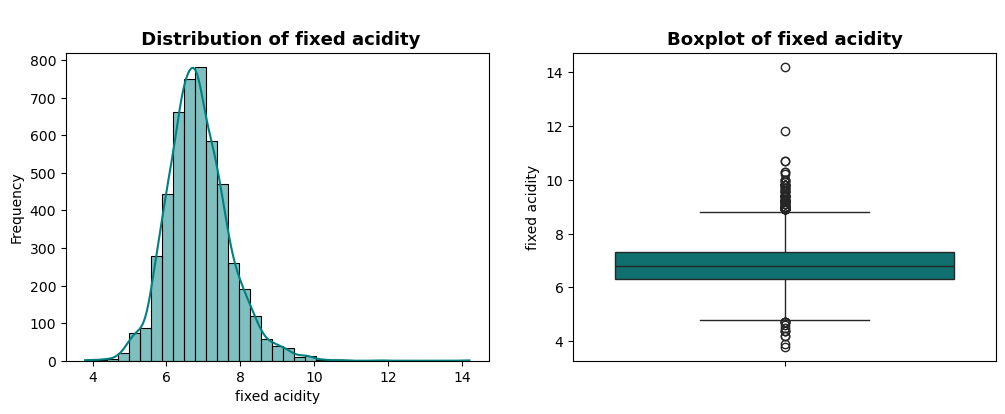

fixed acidity is moderately skewed.

------------------------------------------------------------------------
Feature: volatile acidity
------------------------------------------------------------------------
                   count      mean       std   min   25%   50%   75%  max
volatile acidity  4898.0  0.278241  0.100795  0.08  0.21  0.26  0.32  1.1

Skewness: 1.577
Kurtosis: 5.092


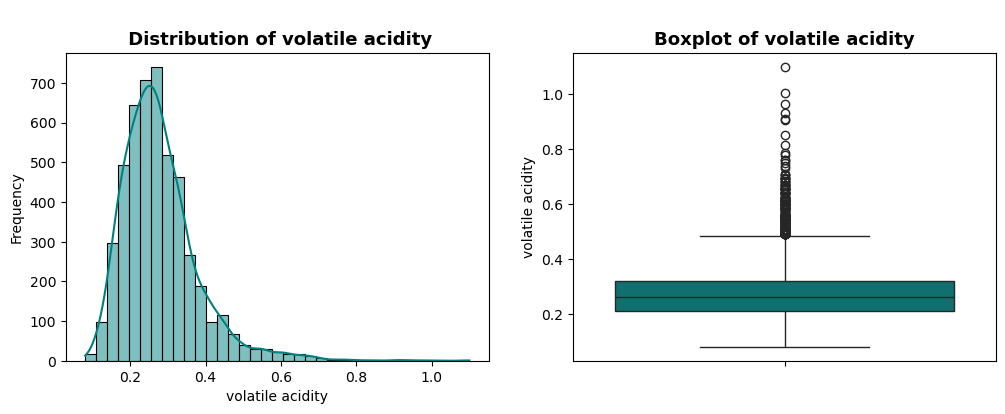


 volatile acidity is highly skewed. Consider log or Box-Cox transformation.

------------------------------------------------------------------------
Feature: citric acid
------------------------------------------------------------------------
              count      mean      std  min   25%   50%   75%   max
citric acid  4898.0  0.334192  0.12102  0.0  0.27  0.32  0.39  1.66

Skewness: 1.282
Kurtosis: 6.175


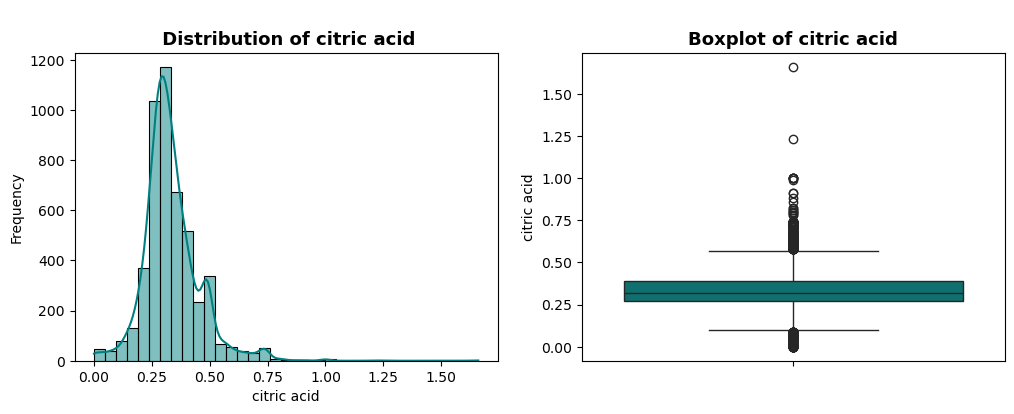


 citric acid is highly skewed. Consider log or Box-Cox transformation.

------------------------------------------------------------------------
Feature: residual sugar
------------------------------------------------------------------------
                 count      mean       std  min  25%  50%  75%   max
residual sugar  4898.0  6.391415  5.072058  0.6  1.7  5.2  9.9  65.8

Skewness: 1.077
Kurtosis: 3.470


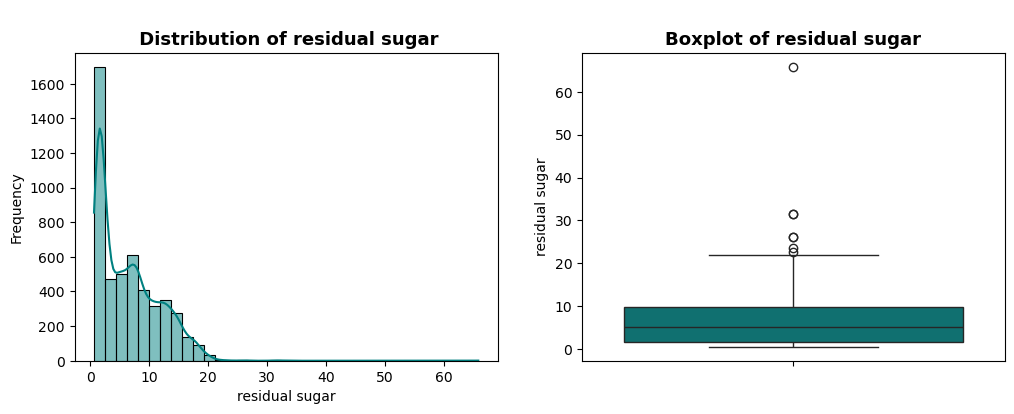


 residual sugar is highly skewed. Consider log or Box-Cox transformation.

------------------------------------------------------------------------
Feature: chlorides
------------------------------------------------------------------------
            count      mean       std    min    25%    50%   75%    max
chlorides  4898.0  0.045772  0.021848  0.009  0.036  0.043  0.05  0.346

Skewness: 5.023
Kurtosis: 37.565


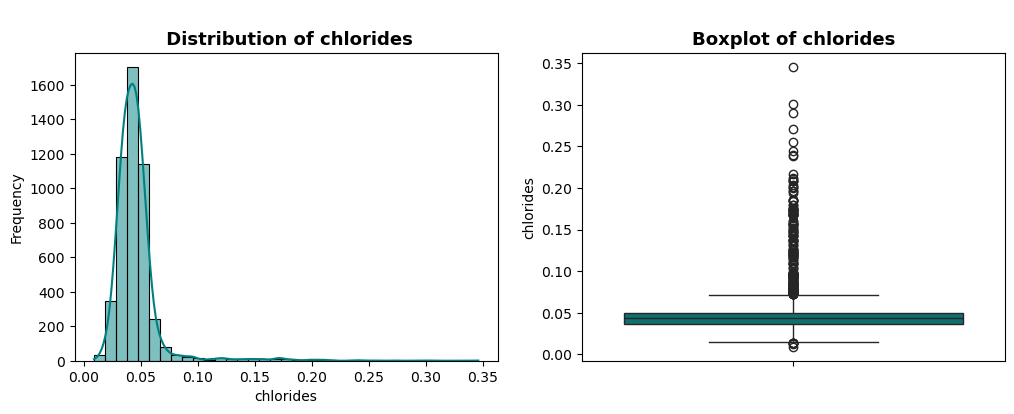


 chlorides is highly skewed. Consider log or Box-Cox transformation.

------------------------------------------------------------------------
Feature: free sulfur dioxide
------------------------------------------------------------------------
                      count       mean        std  min   25%   50%   75%  \
free sulfur dioxide  4898.0  35.308085  17.007137  2.0  23.0  34.0  46.0   

                       max  
free sulfur dioxide  289.0  

Skewness: 1.407
Kurtosis: 11.466


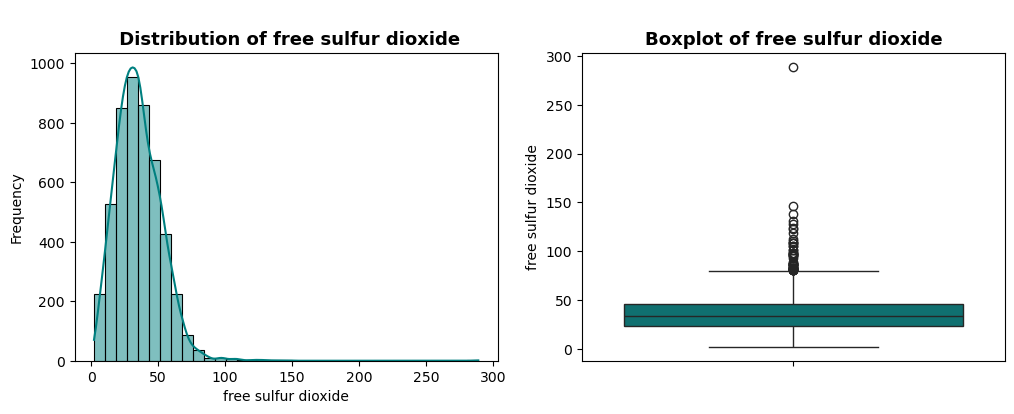


 free sulfur dioxide is highly skewed. Consider log or Box-Cox transformation.

------------------------------------------------------------------------
Feature: total sulfur dioxide
------------------------------------------------------------------------
                       count        mean        std  min    25%    50%    75%  \
total sulfur dioxide  4898.0  138.360657  42.498065  9.0  108.0  134.0  167.0   

                        max  
total sulfur dioxide  440.0  

Skewness: 0.391
Kurtosis: 0.572


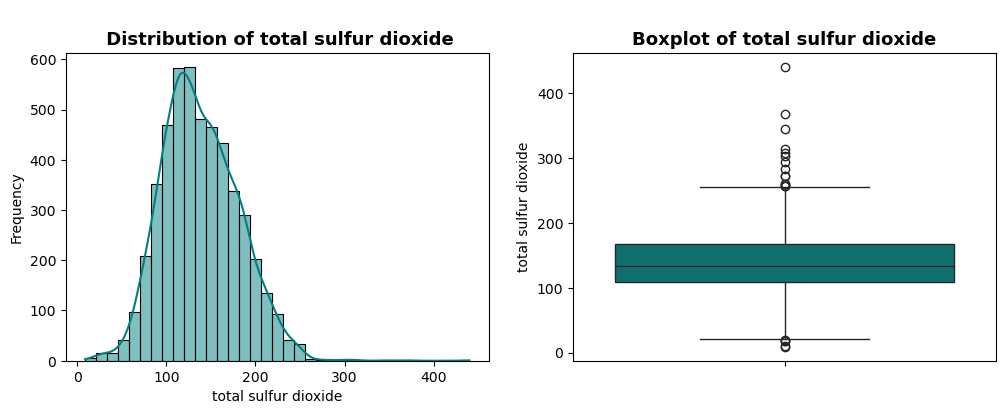

total sulfur dioxide is fairly symmetric.

------------------------------------------------------------------------
Feature: density
------------------------------------------------------------------------
          count      mean       std      min       25%      50%     75%  \
density  4898.0  0.994027  0.002991  0.98711  0.991723  0.99374  0.9961   

             max  
density  1.03898  

Skewness: 0.978
Kurtosis: 9.794


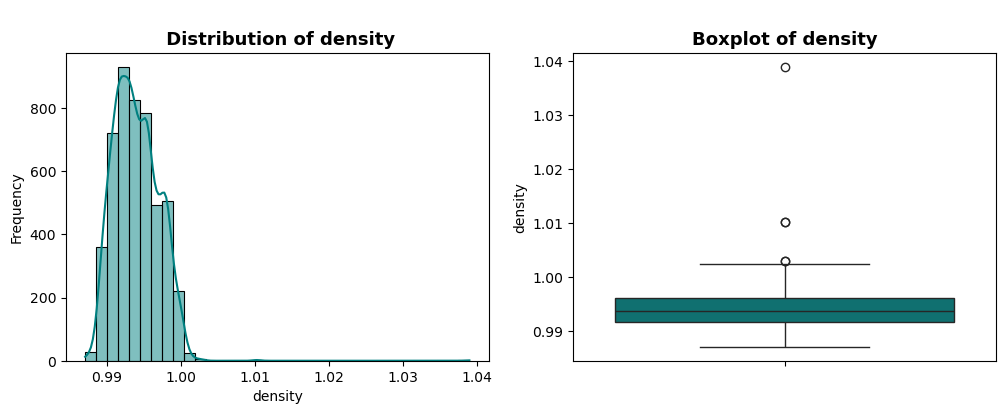

density is moderately skewed.

------------------------------------------------------------------------
Feature: pH
------------------------------------------------------------------------
     count      mean       std   min   25%   50%   75%   max
pH  4898.0  3.188267  0.151001  2.72  3.09  3.18  3.28  3.82

Skewness: 0.458
Kurtosis: 0.531


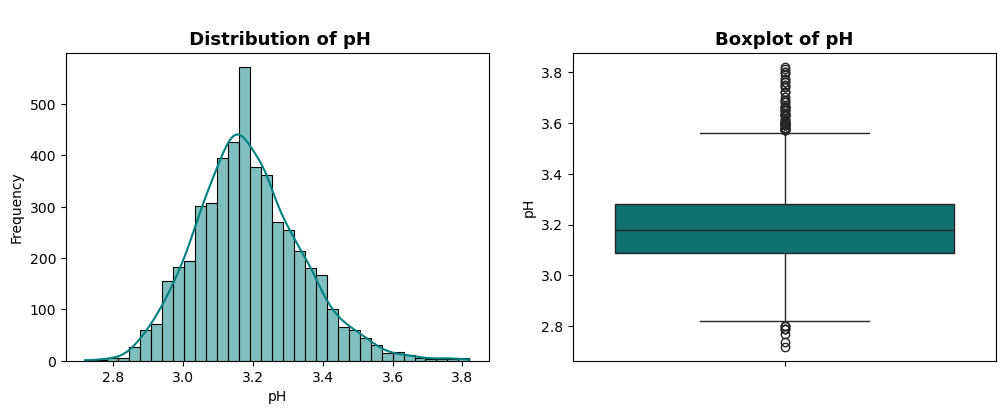

pH is fairly symmetric.

------------------------------------------------------------------------
Feature: sulphates
------------------------------------------------------------------------
            count      mean       std   min   25%   50%   75%   max
sulphates  4898.0  0.489847  0.114126  0.22  0.41  0.47  0.55  1.08

Skewness: 0.977
Kurtosis: 1.591


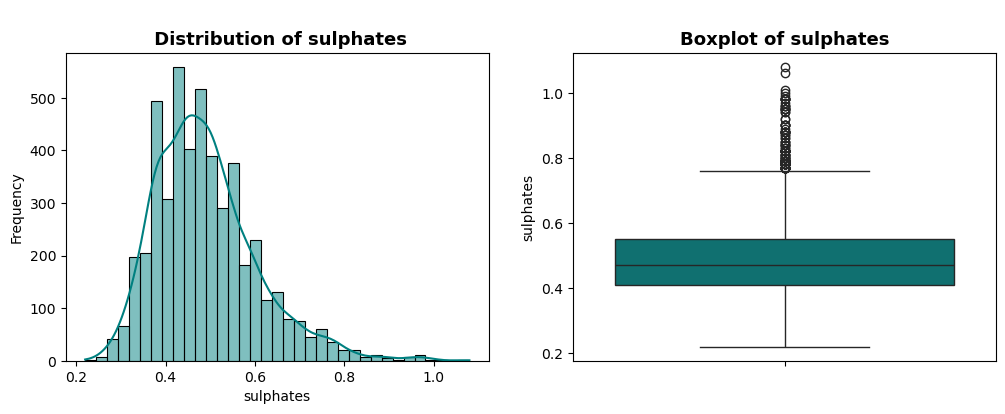

sulphates is moderately skewed.

------------------------------------------------------------------------
Feature: alcohol
------------------------------------------------------------------------
          count       mean       std  min  25%   50%   75%   max
alcohol  4898.0  10.514267  1.230621  8.0  9.5  10.4  11.4  14.2

Skewness: 0.487
Kurtosis: -0.698


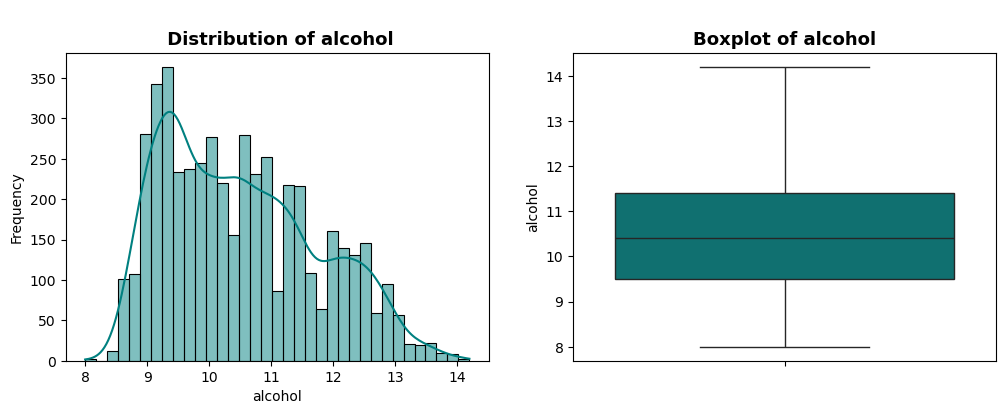

alcohol is fairly symmetric.

------------------------------------------------------------------------
Feature: quality
------------------------------------------------------------------------
          count      mean       std  min  25%  50%  75%  max
quality  4898.0  5.877909  0.885639  3.0  5.0  6.0  6.0  9.0

Skewness: 0.156
Kurtosis: 0.217


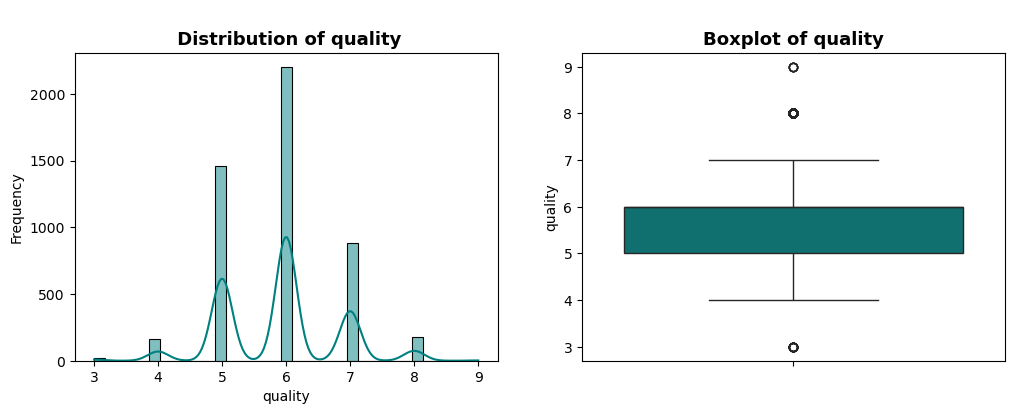

quality is fairly symmetric.



In [71]:
# let loop 2ru our fuction with each feature

for column in numeric_cols:
    univariate_analysis(df,column)
    

### Univariate analysis for categorical feature/coulmn


In [72]:
# let define fuction for univariate on categorical feature
# Displays frequency table, proportion, and a countplot.

def univariate_analysis_cat(df, column):
    print("--"*36)
    print (f"Feature: {column}")
    print("--"*36)

    # frequncy table
    freq= df[column].value_counts()
    prop= df[column].value_counts(normalize=True) * 100
    summary= pd.DataFrame({"Count":freq, "Percentage":prop.round(2)})
    print(summary)
    print()

    # counter plot
    plt.figure(figsize=(8,6))
    ax=sns.countplot(x=column,data=df, hue=column, order=freq.index)
    plt.title(f'\nDistribution of {column}', fontsize=13, fontweight="bold")
    plt.xlabel(column)
    plt.ylabel("Count")

    # display percentage on each bar
    tot= len(df[column])
    for b in ax.patches:
        height= b.get_height()
        ax.text(b.get_x()+ b.get_width()/2, height+1,
                f'{(height/tot)*100:.1f}%',ha='center')

    plt.tight_layout()
    plt.show()

    

In [73]:
# let get the categorical feature
categorical_cols= df.select_dtypes(["object"]).columns
categorical_cols

Index(['quality_value'], dtype='object')

------------------------------------------------------------------------
Feature: quality_value
------------------------------------------------------------------------
               Count  Percentage
quality_value                   
Medium          3655       74.62
High            1060       21.64
Low              183        3.74



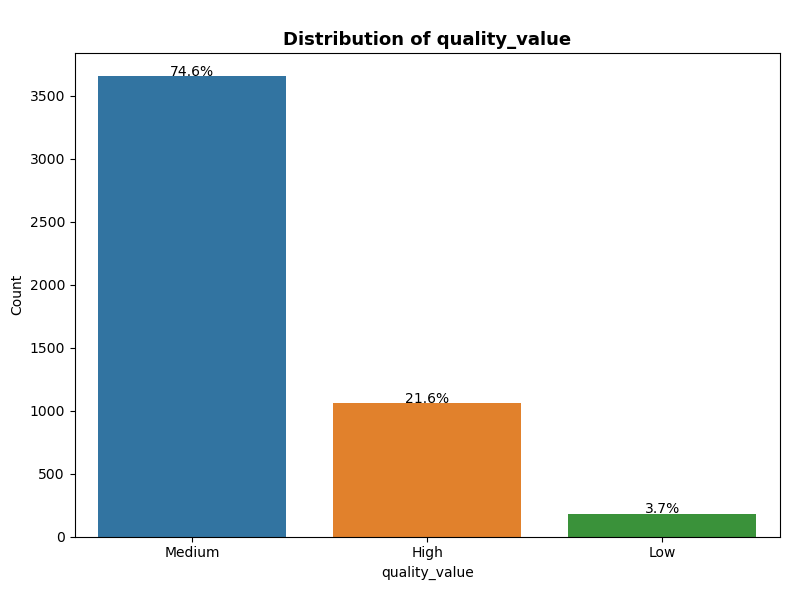

In [74]:
# let use the function
univariate_analysis_cat(df,"quality_value")

### Key Univariate Findings

| Feature Type          |Observation                                  | What It Means / Implication          |
| ----------------------| ------------------------------------------- | ------------------------------------ |
|Most of numeric features| are continous, but several like total sulfur dioxide, chlorides, residual sugar,  citric acid and volatile acidity are right-skewed| These can distort algorithms that sensitive to scalling like KNN and linear regression. So, Box-Cox or log transformation could be considered|
|

## Bivariate Analysis

The goals is to understand how two variables relate, especially how input **features** relate to the **target**.
1. Numerical to numerical
2. Numerical to categorical

In [75]:
# showing the correlation of each numeric features with the target using heatmap
def Bivariate_num_to_num(df, target):
    # get d numeric only
    numeric_cols= df.select_dtypes(include='number').copy()
    if target not in numeric_cols.columns:
        raise ValueError(f"Target colunm {target} must be numeric and present in the dataframe")

    # let find the correlation
    corr = numeric_cols.corrwith(numeric_cols[target]).drop(target)
    corr_df=corr.to_frame(name="corr").T

    # let plot
    plt.figure(figsize=(10,2))
    sns.heatmap(corr_df,cmap="coolwarm",fmt=".3f", annot=True, cbar={"orientation":"vertical","shrink":0.7}, vmin=-1, vmax=1)

    plt.title(f'Correlation of numeric features with {target}', fontsize=12)
    plt.xticks( rotation=45, ha="right")
    plt.yticks([0], [target], rotation=0)

    plt.tight_layout()   
    plt.show()

    # return sorted correlation
    return corr.reindex(corr.abs().sort_values(ascending=False).index)

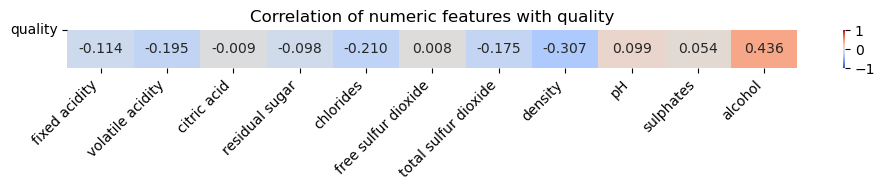

alcohol                 0.435575
density                -0.307123
chlorides              -0.209934
volatile acidity       -0.194723
total sulfur dioxide   -0.174737
fixed acidity          -0.113663
pH                      0.099427
residual sugar         -0.097577
sulphates               0.053678
citric acid            -0.009209
free sulfur dioxide     0.008158
dtype: float64


In [76]:
corr_series= Bivariate_num_to_num(df,"quality")
print(corr_series)

### Numerical Vs Numerical features 

In [77]:
from scipy.stats import pearsonr
# let spot the relationship btw numeric features
def numeric_bivariate_plot(df, feature1, feature2, treshold):
    # calculte the correlation coefficient
    corr,p_value= pearsonr(df[feature1], df[feature2])
    if abs(corr) < treshold:
        print(f"Skipped {feature1} vs {feature2} because it is too weak correlation")
        return #skipped the plot for weak correclation
    color = "red" if corr < 0 else "green" #set color for positive or negatitve corr
# let plot
    plt.figure(figsize=(8,5))
    sns.regplot(data=df, x=feature1, y=feature2, scatter_kws={"alpha":0.5}, line_kws={"color":color})
    plt.title(f"{feature1} vs {feature2}\nCorrelation: {corr:.3f} (p={p_value:.3f})", fontsize=13)
    plt.xlabel(feature1, fontsize=11)
    plt.ylabel(feature2, fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()


In [78]:
# let check numeric columns for all possible combinations
numeric_cols= df.select_dtypes(include='number').columns.copy()
numeric_cols

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

Skipped fixed acidity vs volatile acidity because it is too weak correlation


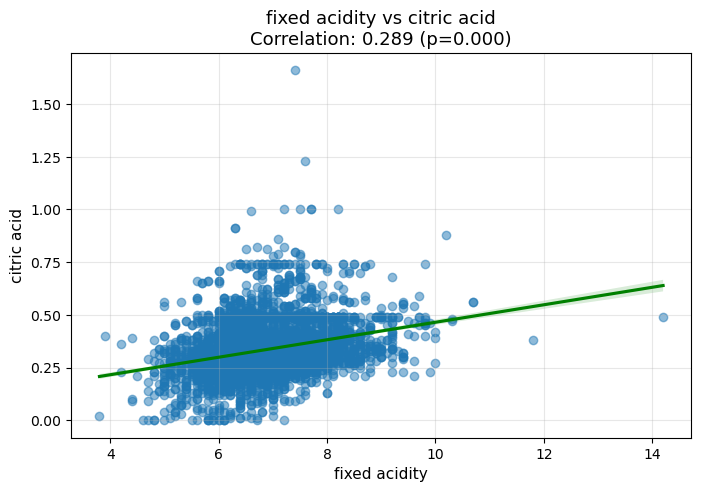

Skipped fixed acidity vs residual sugar because it is too weak correlation
Skipped fixed acidity vs chlorides because it is too weak correlation
Skipped fixed acidity vs free sulfur dioxide because it is too weak correlation
Skipped fixed acidity vs total sulfur dioxide because it is too weak correlation


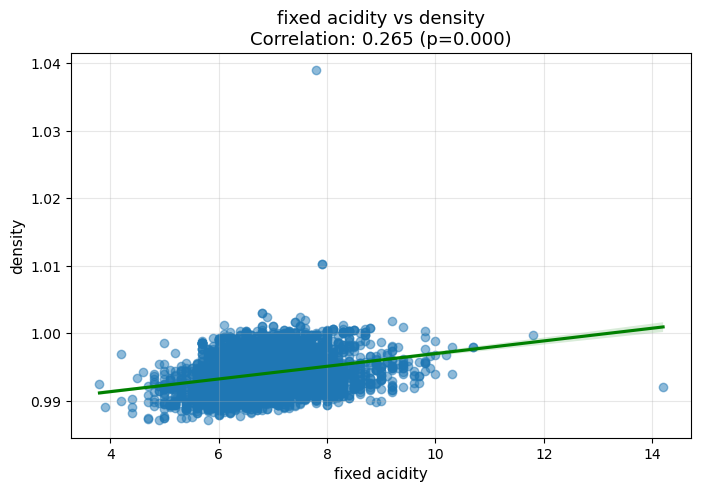

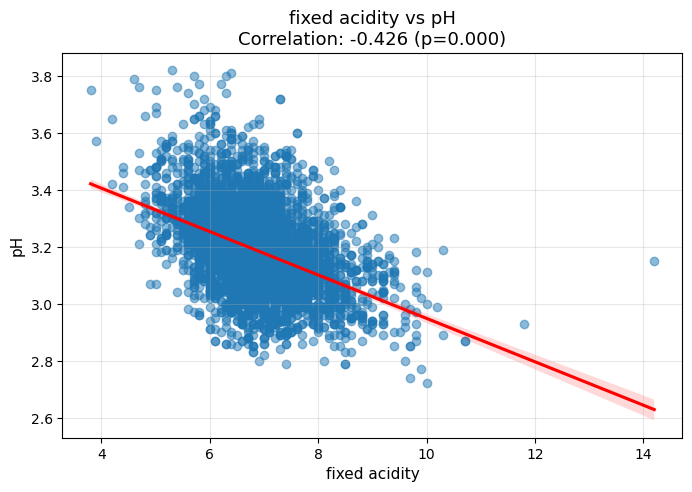

Skipped fixed acidity vs sulphates because it is too weak correlation
Skipped fixed acidity vs alcohol because it is too weak correlation
Skipped fixed acidity vs quality because it is too weak correlation
Skipped volatile acidity vs citric acid because it is too weak correlation
Skipped volatile acidity vs residual sugar because it is too weak correlation
Skipped volatile acidity vs chlorides because it is too weak correlation
Skipped volatile acidity vs free sulfur dioxide because it is too weak correlation
Skipped volatile acidity vs total sulfur dioxide because it is too weak correlation
Skipped volatile acidity vs density because it is too weak correlation
Skipped volatile acidity vs pH because it is too weak correlation
Skipped volatile acidity vs sulphates because it is too weak correlation
Skipped volatile acidity vs alcohol because it is too weak correlation
Skipped volatile acidity vs quality because it is too weak correlation
Skipped citric acid vs residual sugar because it 

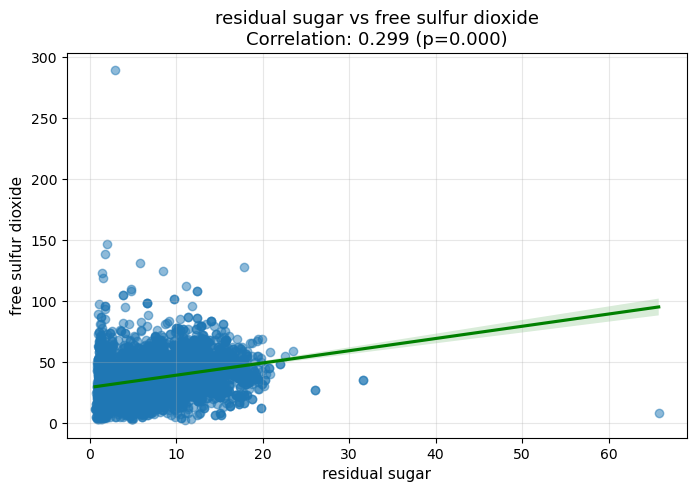

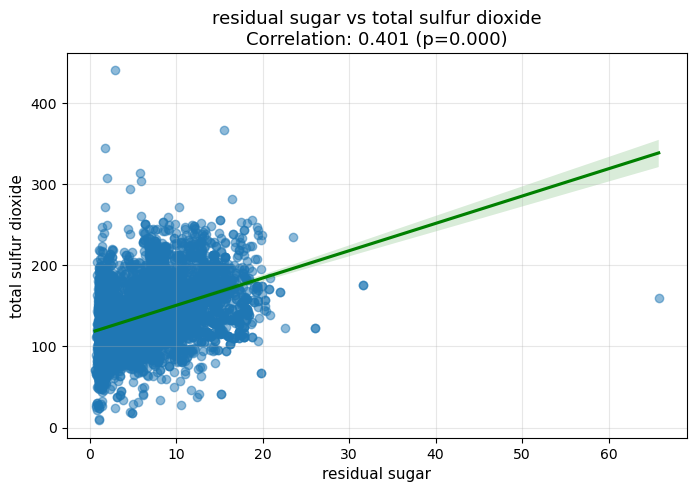

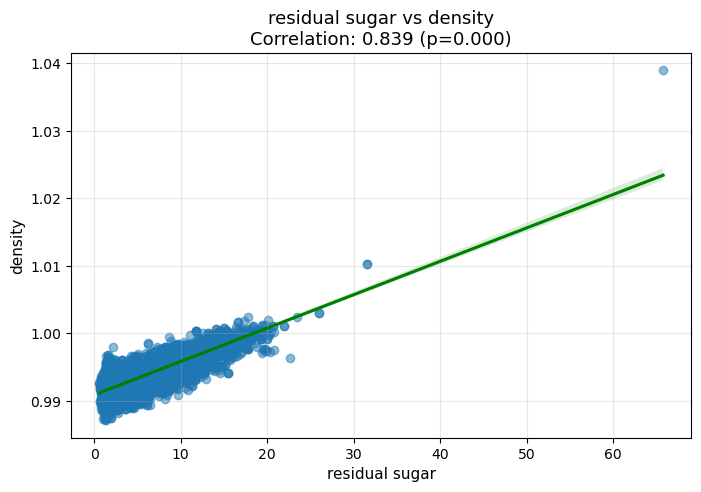

Skipped residual sugar vs pH because it is too weak correlation
Skipped residual sugar vs sulphates because it is too weak correlation


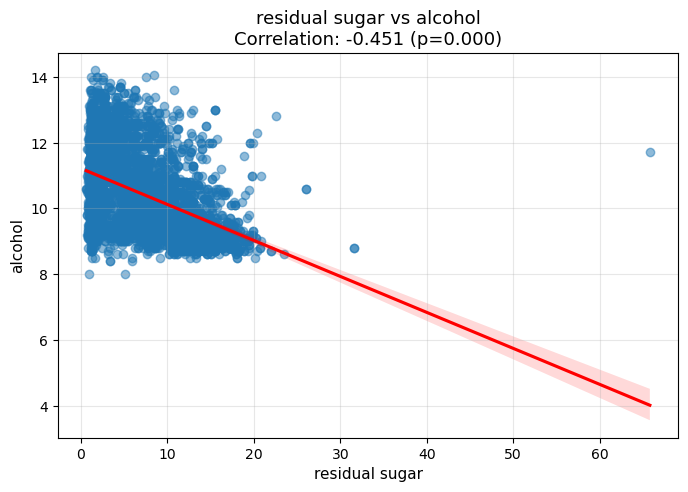

Skipped residual sugar vs quality because it is too weak correlation
Skipped chlorides vs free sulfur dioxide because it is too weak correlation
Skipped chlorides vs total sulfur dioxide because it is too weak correlation


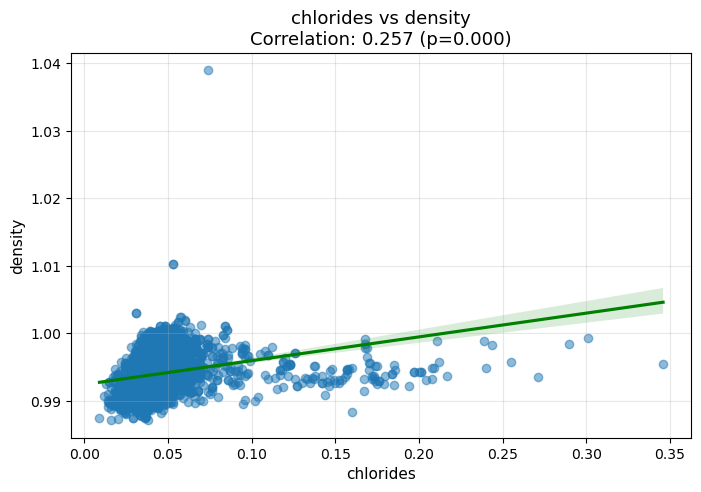

Skipped chlorides vs pH because it is too weak correlation
Skipped chlorides vs sulphates because it is too weak correlation


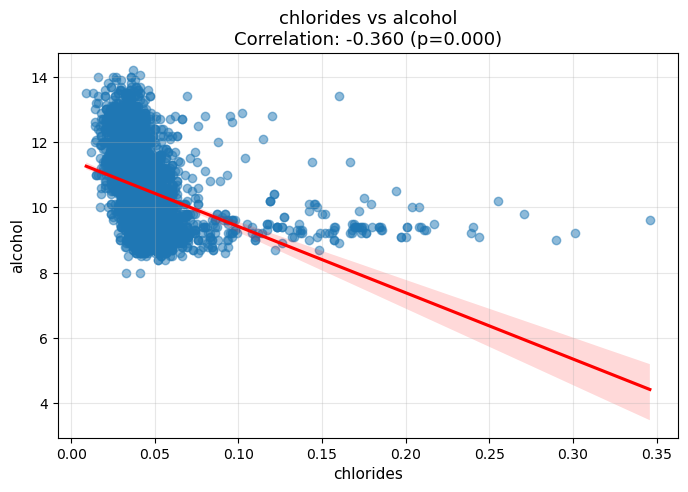

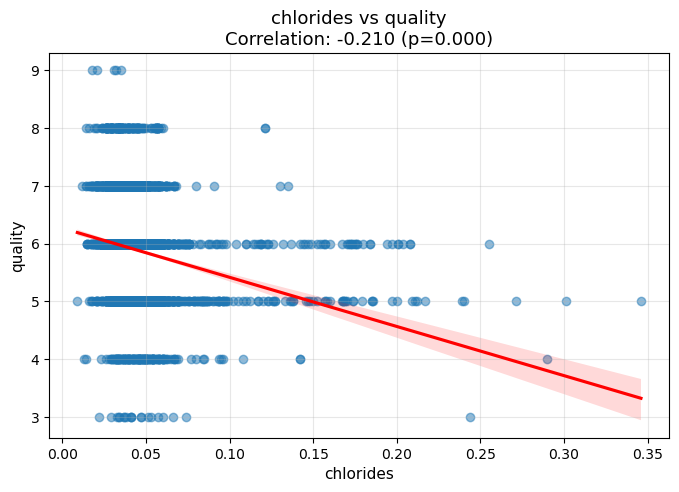

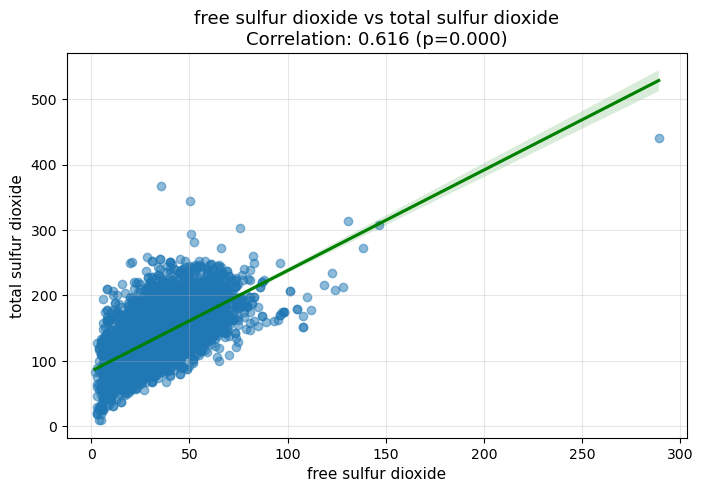

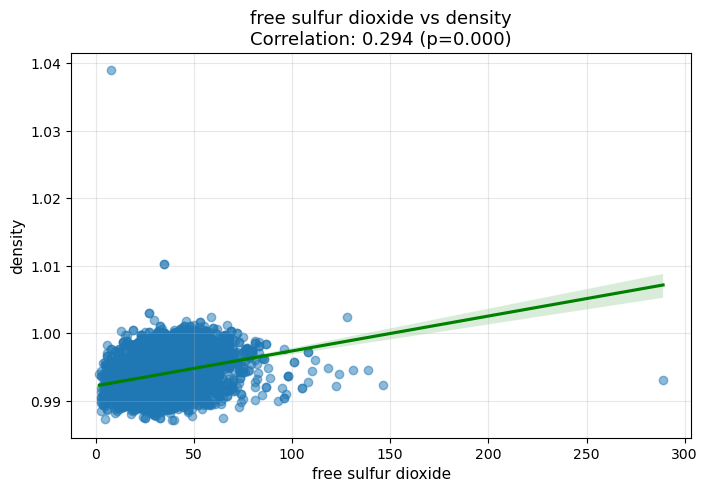

Skipped free sulfur dioxide vs pH because it is too weak correlation
Skipped free sulfur dioxide vs sulphates because it is too weak correlation


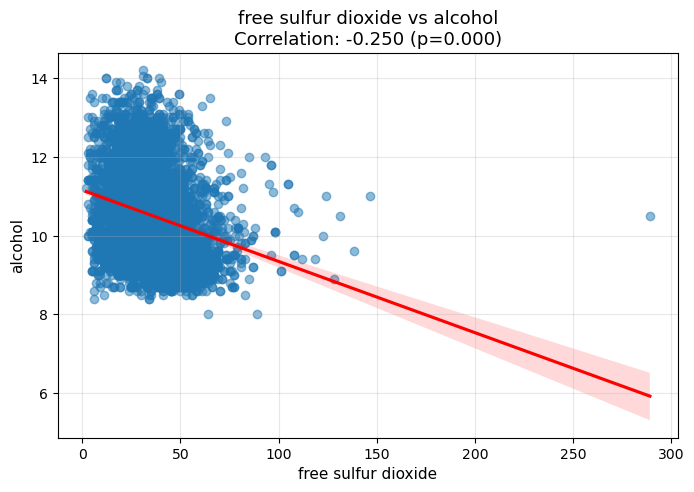

Skipped free sulfur dioxide vs quality because it is too weak correlation


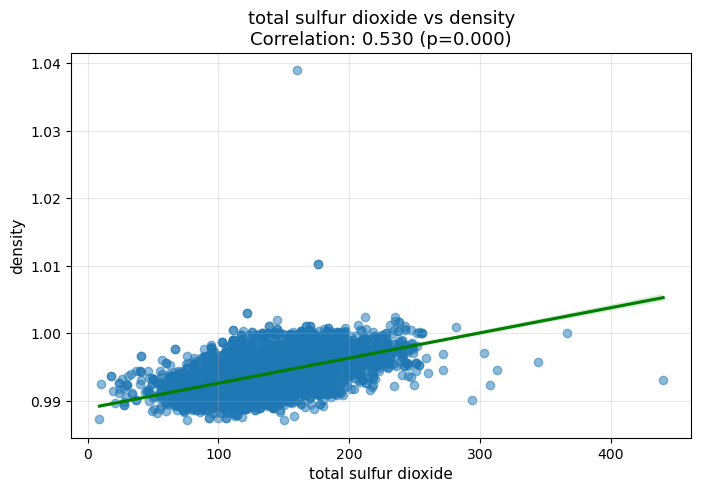

Skipped total sulfur dioxide vs pH because it is too weak correlation
Skipped total sulfur dioxide vs sulphates because it is too weak correlation


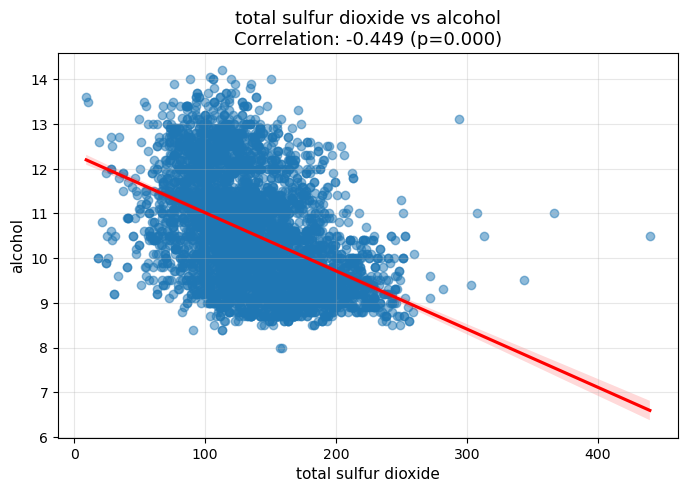

Skipped total sulfur dioxide vs quality because it is too weak correlation
Skipped density vs pH because it is too weak correlation
Skipped density vs sulphates because it is too weak correlation


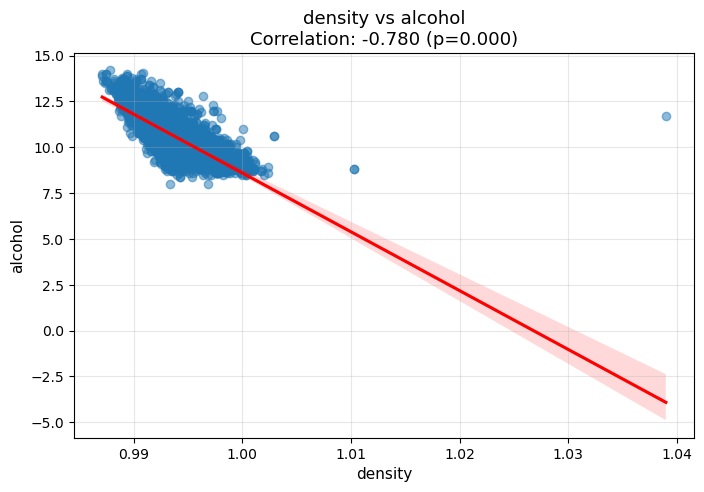

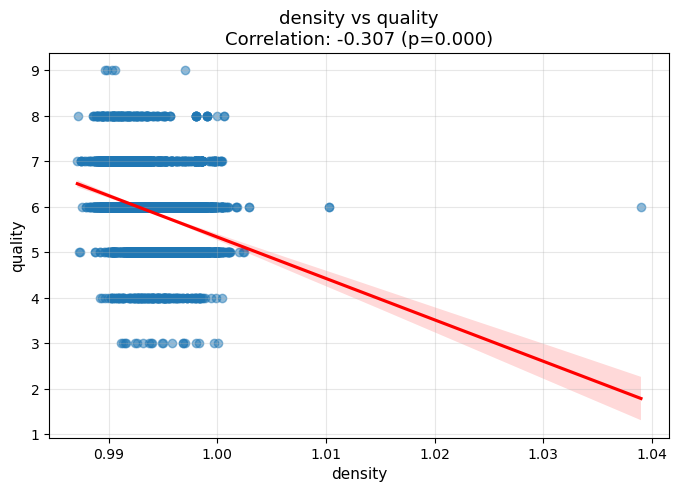

Skipped pH vs sulphates because it is too weak correlation
Skipped pH vs alcohol because it is too weak correlation
Skipped pH vs quality because it is too weak correlation
Skipped sulphates vs alcohol because it is too weak correlation
Skipped sulphates vs quality because it is too weak correlation


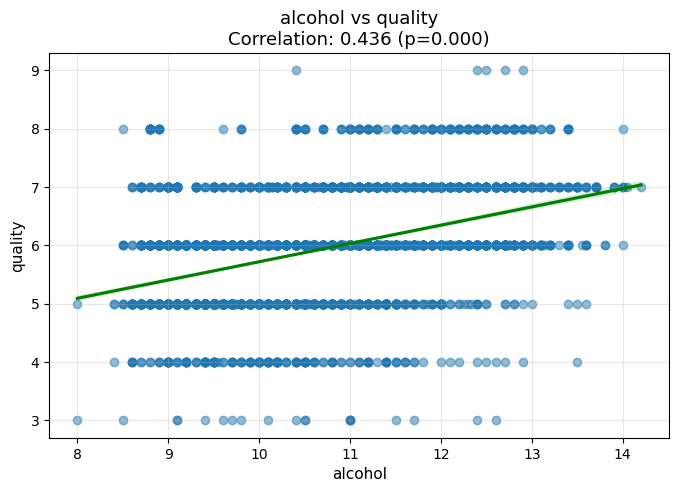

In [79]:
# let plot all the possible combination of each variable.
# Note the function will skip the 
import itertools
for f1, f2 in itertools.combinations(numeric_cols,2):
    numeric_bivariate_plot(df=df,feature1=f1,feature2=f2, treshold=0.2)

### Numeric–Categorical (Feature vs Target)**

In [80]:
# Plots and summarizes relationship between a numerical feature and a categorical target.
def bivariate_num_cat(df,feature, target):
    print()
    print("="*50)
    print(f"Feature: {feature} vs {target}")
    print("="*50)

    # prepare
    summary= df.groupby(target)[feature].describe()[["mean","std","min","max"]]
    print(summary.round(2))
    print()

    # plotting box plot
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    sns.boxplot(x=target, y=feature, data=df, hue=target)
    plt.title(f"Box plot of {feature} vs {target}")
    plt.xlabel(target)
    plt.ylabel(feature)

    # plotting violin plot
    plt.subplot(1,2,2)
    sns.violinplot(x=target,y=feature,data=df,hue=target)
    plt.title(f"Violin plot of {feature} vs {target}")
    plt.xlabel(target)
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

In [81]:
white_wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'quality_value'],
      dtype='object')


Feature: fixed acidity vs quality_value
               mean   std  min   max
quality_value                       
High           6.73  0.77  3.9   9.2
Low            7.18  1.17  4.2  11.8
Medium         6.88  0.84  3.8  14.2



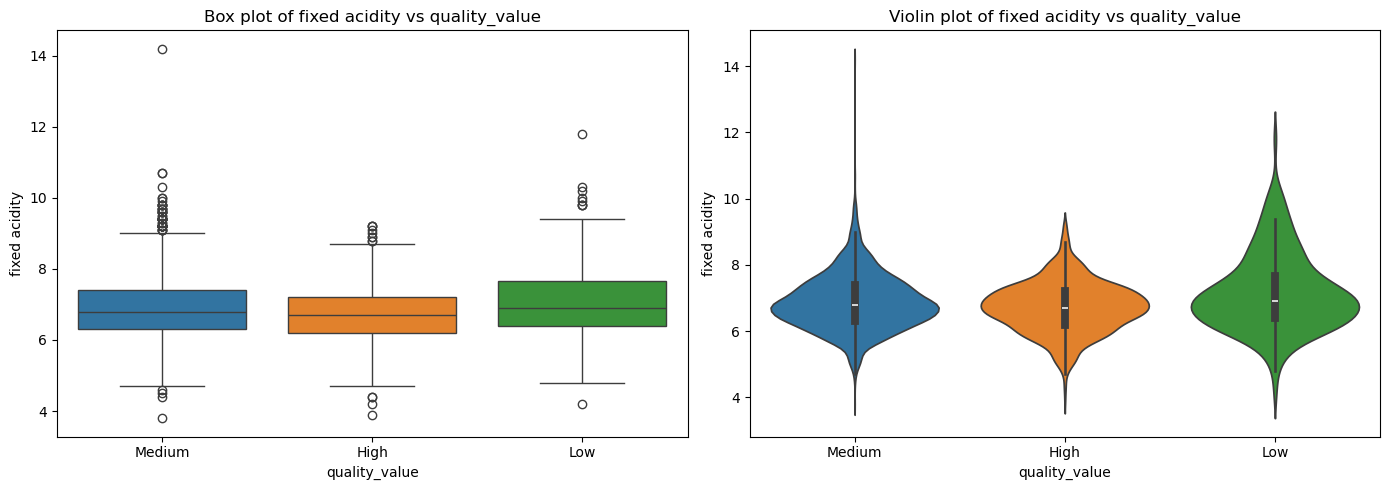


Feature: volatile acidity vs quality_value
               mean   std   min   max
quality_value                        
High           0.27  0.09  0.08  0.76
Low            0.38  0.17  0.11  1.10
Medium         0.28  0.10  0.08  0.96



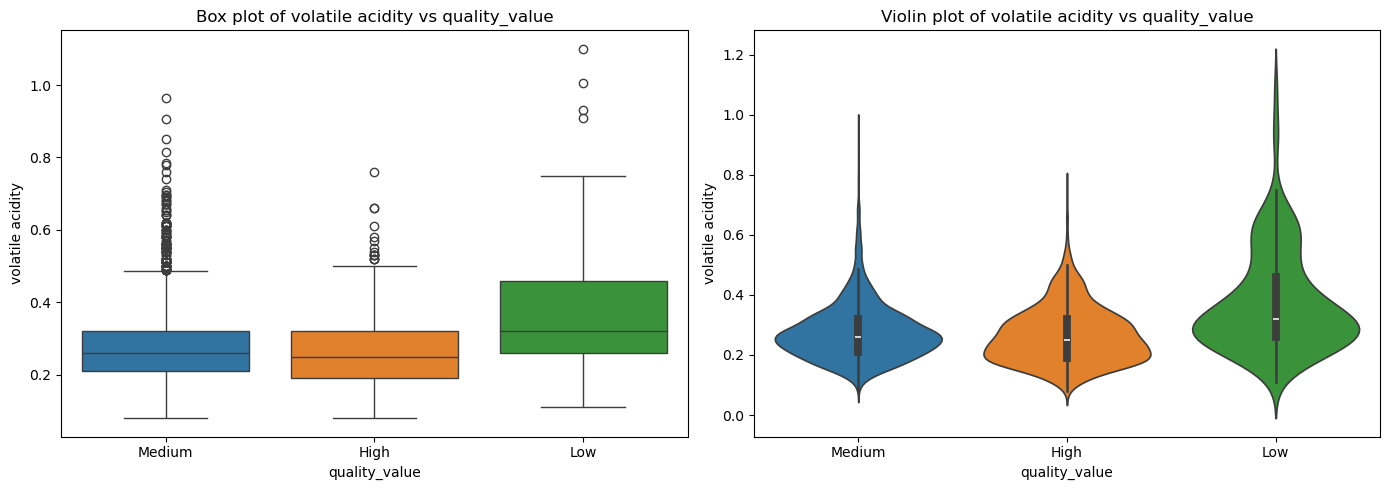


Feature: citric acid vs quality_value
               mean   std   min   max
quality_value                        
High           0.33  0.08  0.01  0.74
Low            0.31  0.16  0.00  0.88
Medium         0.34  0.13  0.00  1.66



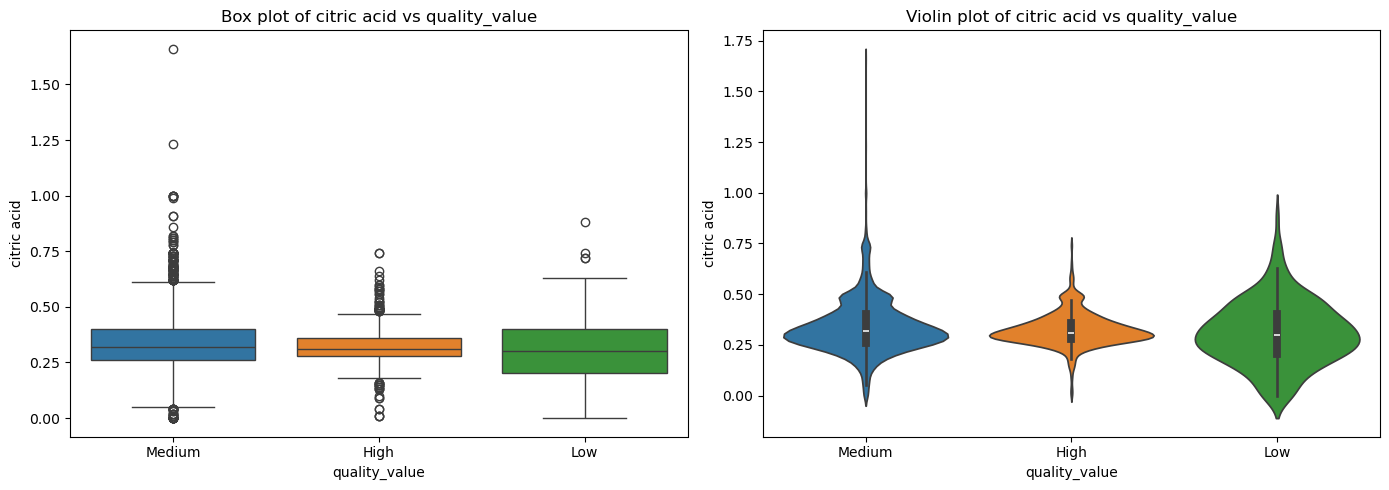


Feature: residual sugar vs quality_value
               mean   std  min    max
quality_value                        
High           5.26  4.29  0.8  19.25
Low            4.82  4.32  0.7  17.55
Medium         6.80  5.25  0.6  65.80



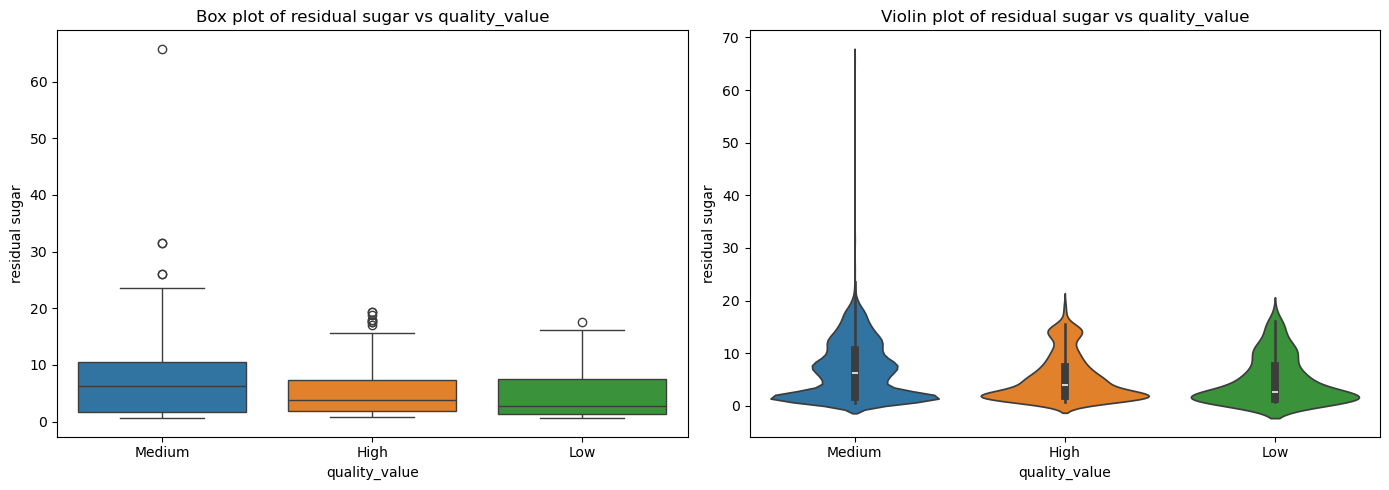


Feature: chlorides vs quality_value
               mean   std   min   max
quality_value                        
High           0.04  0.01  0.01  0.14
Low            0.05  0.03  0.01  0.29
Medium         0.05  0.02  0.01  0.35



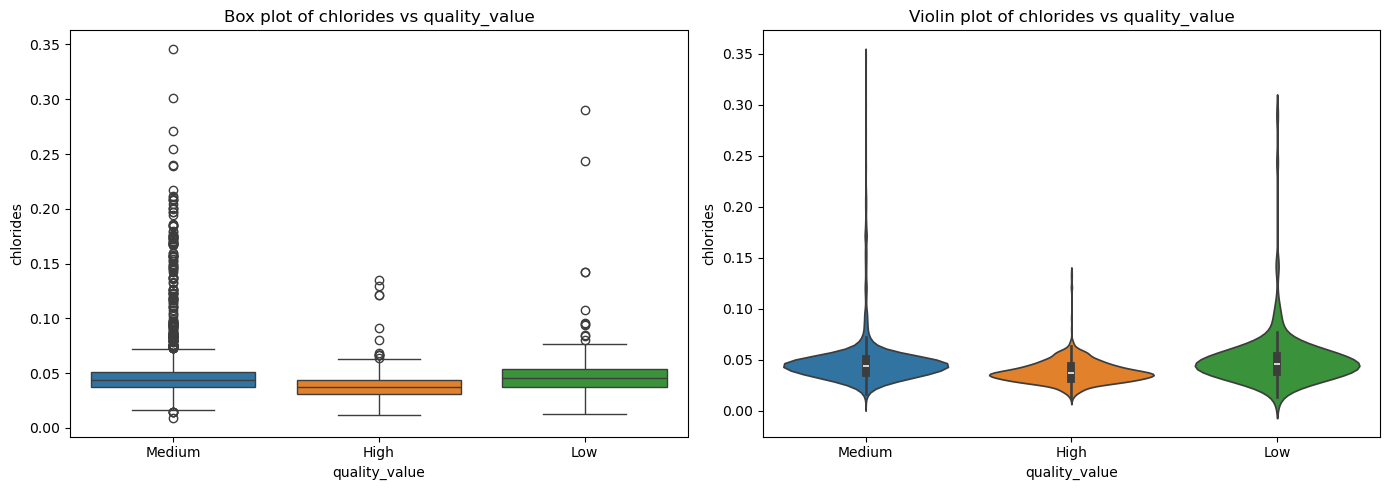


Feature: free sulfur dioxide vs quality_value
                mean    std  min    max
quality_value                          
High           34.55  13.80  5.0  108.0
Low            26.63  31.00  3.0  289.0
Medium         35.96  16.74  2.0  131.0



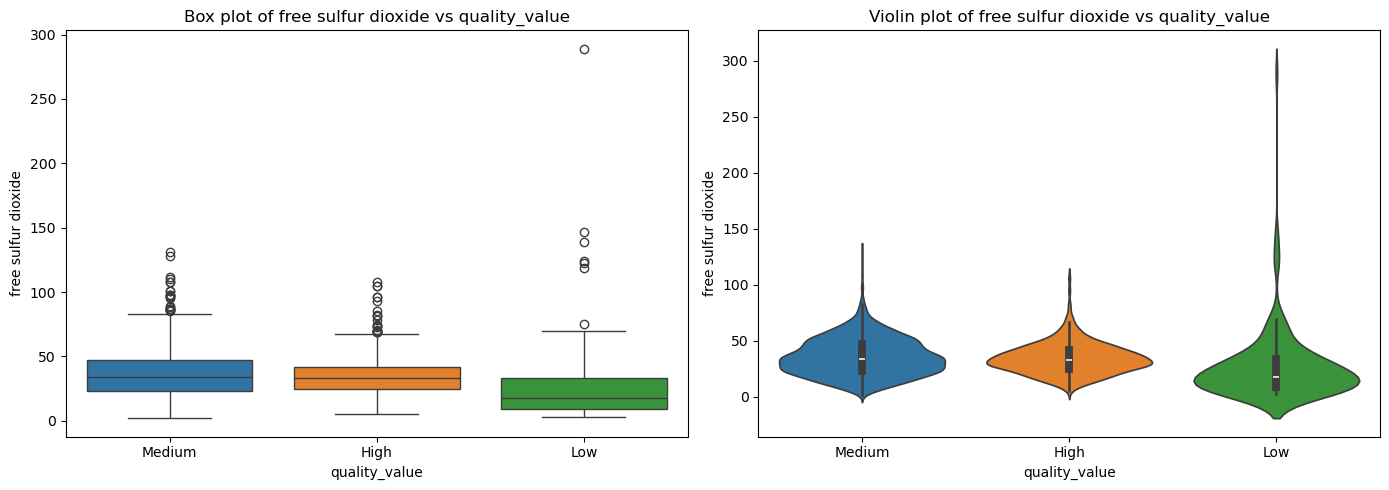


Feature: total sulfur dioxide vs quality_value
                 mean    std   min    max
quality_value                            
High           125.25  32.72  34.0  229.0
Low            130.23  62.37  10.0  440.0
Medium         142.57  42.96   9.0  344.0



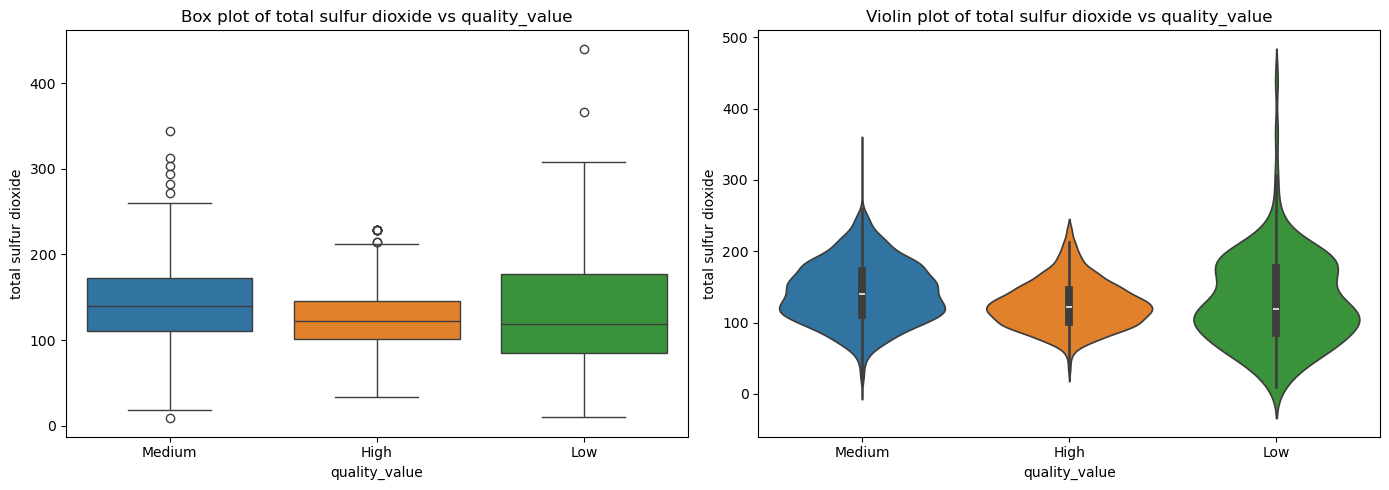


Feature: density vs quality_value
               mean  std   min   max
quality_value                       
High           0.99  0.0  0.99  1.00
Low            0.99  0.0  0.99  1.00
Medium         0.99  0.0  0.99  1.04



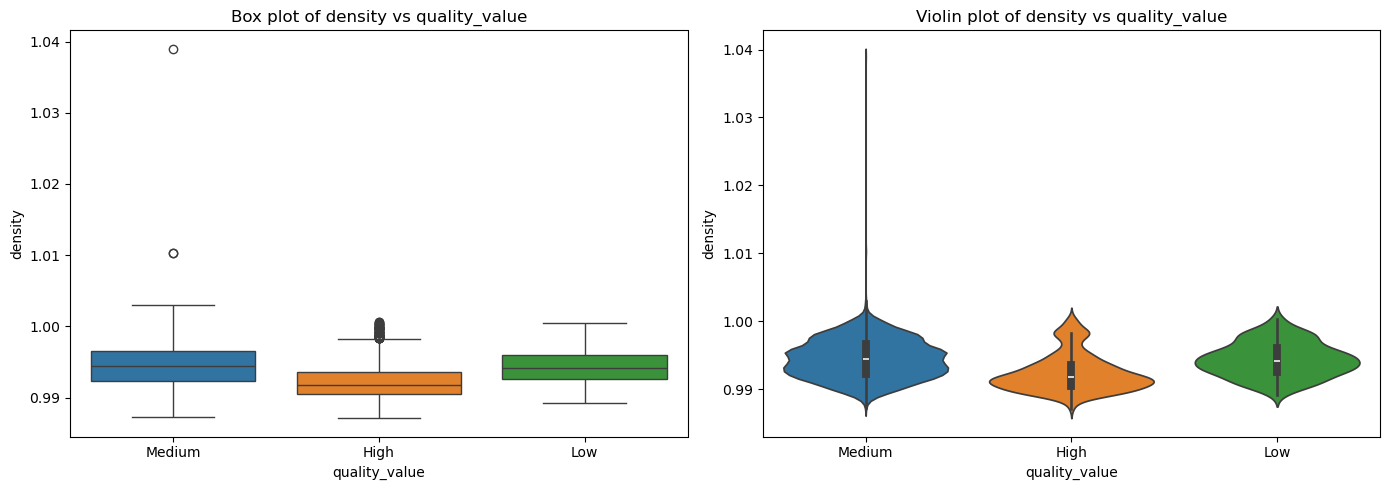


Feature: pH vs quality_value
               mean   std   min   max
quality_value                        
High           3.22  0.16  2.84  3.82
Low            3.18  0.17  2.83  3.72
Medium         3.18  0.15  2.72  3.81



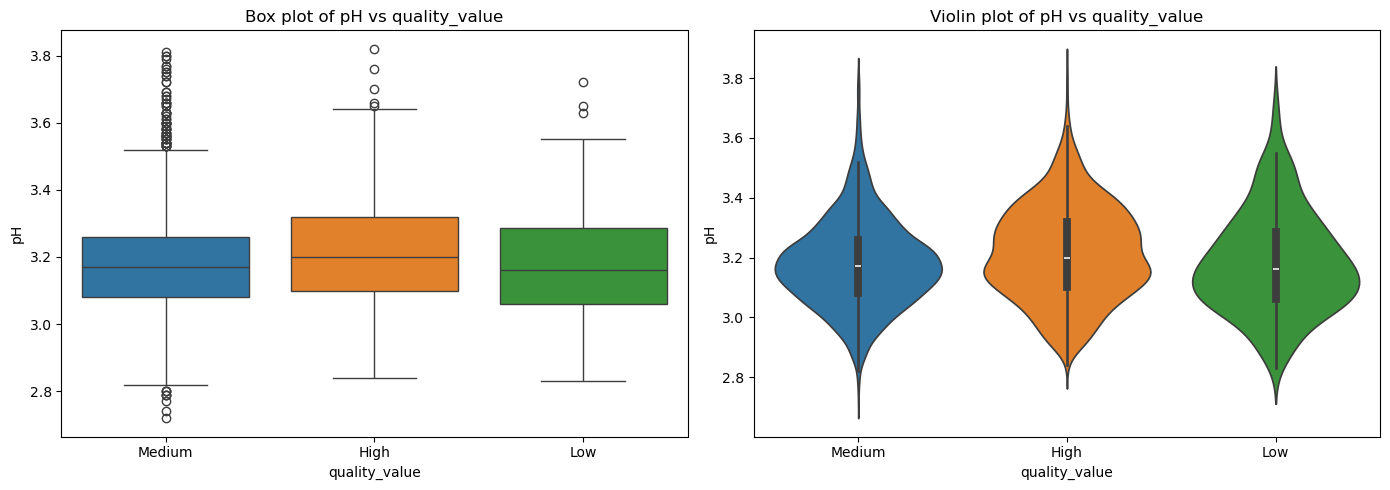


Feature: sulphates vs quality_value
               mean   std   min   max
quality_value                        
High           0.50  0.13  0.22  1.08
Low            0.48  0.12  0.25  0.87
Medium         0.49  0.11  0.23  1.06



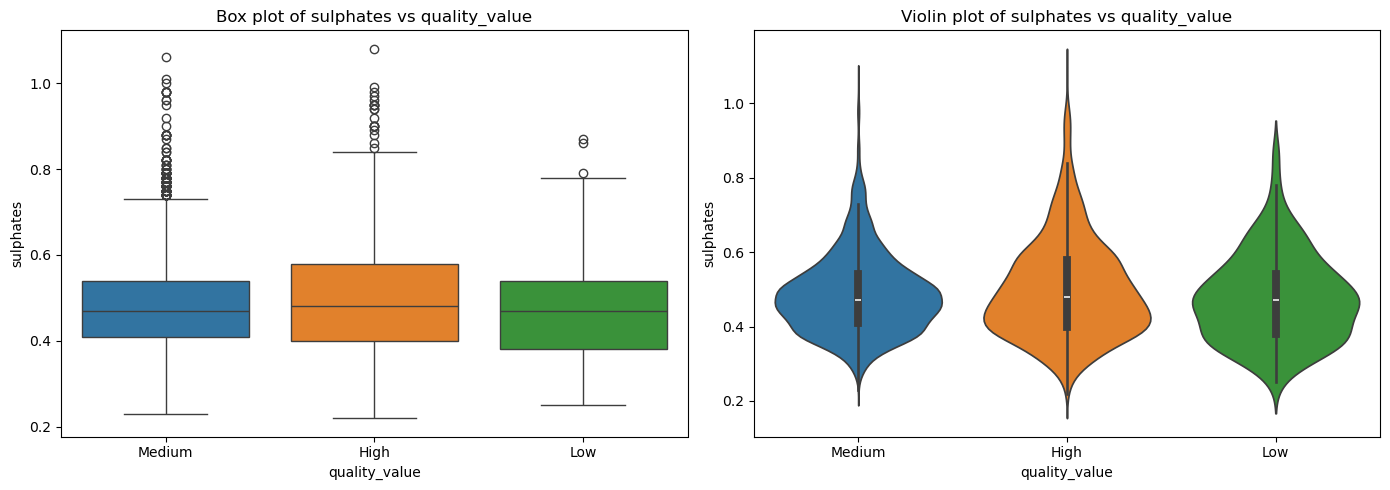


Feature: alcohol vs quality_value
                mean   std  min   max
quality_value                        
High           11.42  1.26  8.5  14.2
Low            10.17  1.03  8.0  13.5
Medium         10.27  1.10  8.0  14.0



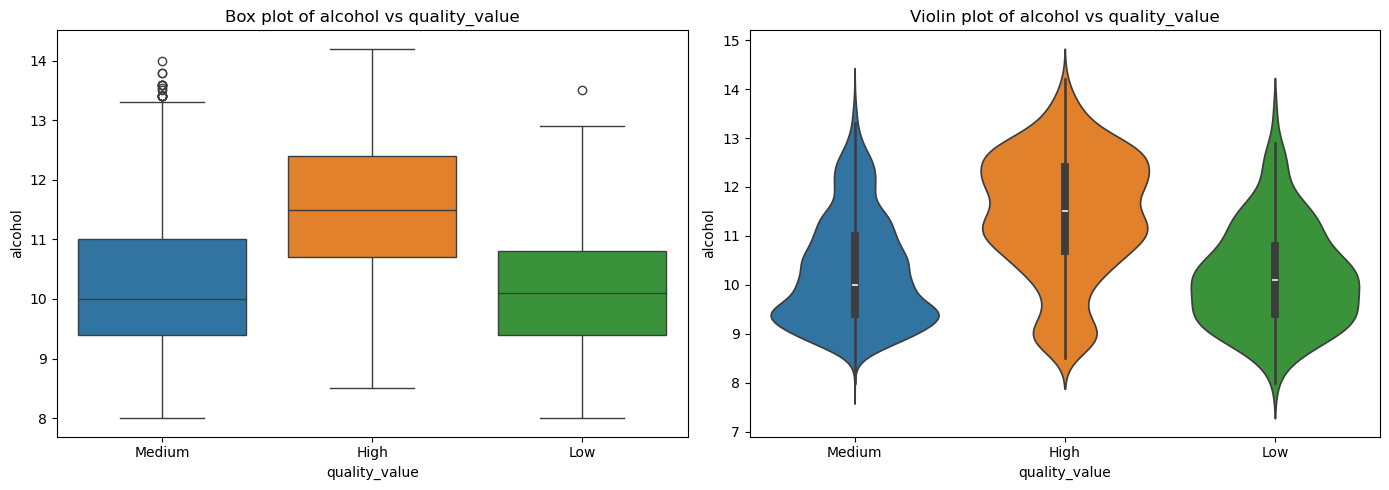


Feature: quality vs quality_value
               mean   std  min  max
quality_value                      
High           7.17  0.39  7.0  9.0
Low            3.89  0.31  3.0  4.0
Medium         5.60  0.49  5.0  6.0



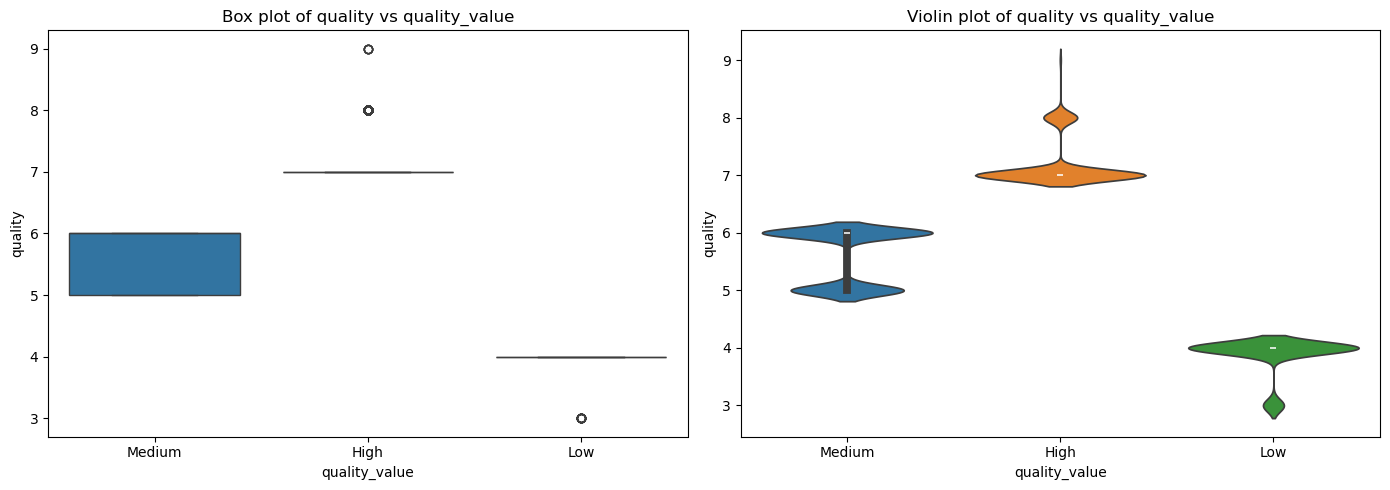

In [82]:
# let loop through the features and use the function
for feature in numeric_cols:
    bivariate_num_cat(df,feature, target="quality_value")

 ## **3. Trivariate analysis**

This introduced hue color or size dimension

In [83]:
def trivarite(df,feature1,feature2, target):
    corr, p_value = pearsonr(df[feature1], df[feature2])
    if abs(corr)<0.3:
        print(f"{feature1} vs {feature2} Skipped, low Correlation")
        return
    print()
    print("="*50)
    print(f"Distrubiton of {feature1} vs {feature2} over the target ({target})")
    print("="*50)
    print()
    
    plt.figure(figsize=(10,6))
    sns.lmplot(data=df, x=feature1, y=feature2, hue=target)
    plt.title(f"{feature1} vs {feature2} by {target}", fontsize=13)
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.grid(alpha=0.3)
    plt.show()

fixed acidity vs volatile acidity Skipped, low Correlation
fixed acidity vs citric acid Skipped, low Correlation
fixed acidity vs residual sugar Skipped, low Correlation
fixed acidity vs chlorides Skipped, low Correlation
fixed acidity vs free sulfur dioxide Skipped, low Correlation
fixed acidity vs total sulfur dioxide Skipped, low Correlation
fixed acidity vs density Skipped, low Correlation

Distrubiton of fixed acidity vs pH over the target (quality_value)



<Figure size 1000x600 with 0 Axes>

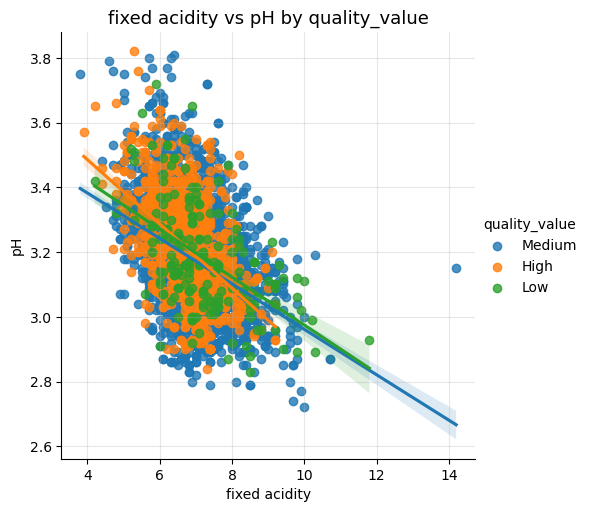

fixed acidity vs sulphates Skipped, low Correlation
fixed acidity vs alcohol Skipped, low Correlation
fixed acidity vs quality Skipped, low Correlation
volatile acidity vs citric acid Skipped, low Correlation
volatile acidity vs residual sugar Skipped, low Correlation
volatile acidity vs chlorides Skipped, low Correlation
volatile acidity vs free sulfur dioxide Skipped, low Correlation
volatile acidity vs total sulfur dioxide Skipped, low Correlation
volatile acidity vs density Skipped, low Correlation
volatile acidity vs pH Skipped, low Correlation
volatile acidity vs sulphates Skipped, low Correlation
volatile acidity vs alcohol Skipped, low Correlation
volatile acidity vs quality Skipped, low Correlation
citric acid vs residual sugar Skipped, low Correlation
citric acid vs chlorides Skipped, low Correlation
citric acid vs free sulfur dioxide Skipped, low Correlation
citric acid vs total sulfur dioxide Skipped, low Correlation
citric acid vs density Skipped, low Correlation
citric ac

<Figure size 1000x600 with 0 Axes>

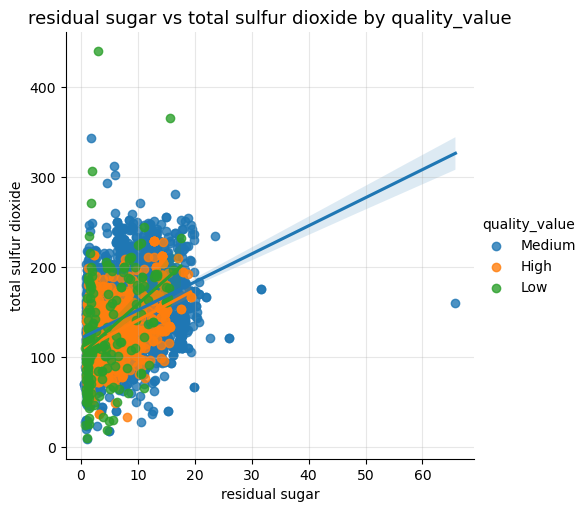


Distrubiton of residual sugar vs density over the target (quality_value)



<Figure size 1000x600 with 0 Axes>

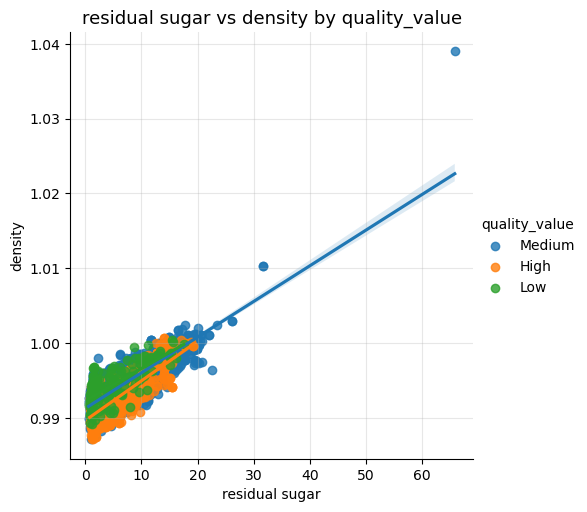

residual sugar vs pH Skipped, low Correlation
residual sugar vs sulphates Skipped, low Correlation

Distrubiton of residual sugar vs alcohol over the target (quality_value)



<Figure size 1000x600 with 0 Axes>

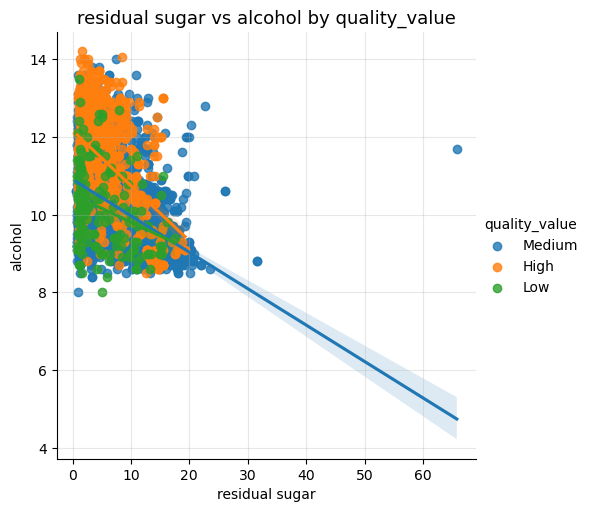

residual sugar vs quality Skipped, low Correlation
chlorides vs free sulfur dioxide Skipped, low Correlation
chlorides vs total sulfur dioxide Skipped, low Correlation
chlorides vs density Skipped, low Correlation
chlorides vs pH Skipped, low Correlation
chlorides vs sulphates Skipped, low Correlation

Distrubiton of chlorides vs alcohol over the target (quality_value)



<Figure size 1000x600 with 0 Axes>

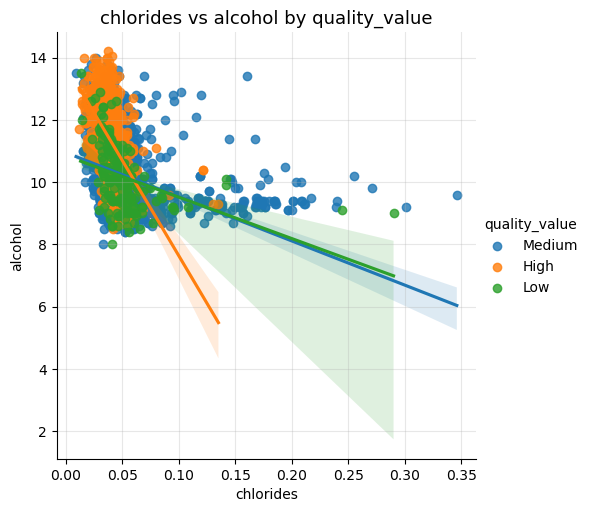

chlorides vs quality Skipped, low Correlation

Distrubiton of free sulfur dioxide vs total sulfur dioxide over the target (quality_value)



<Figure size 1000x600 with 0 Axes>

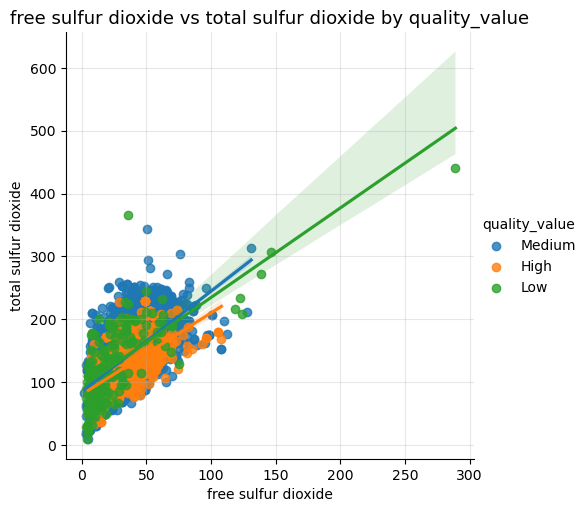

free sulfur dioxide vs density Skipped, low Correlation
free sulfur dioxide vs pH Skipped, low Correlation
free sulfur dioxide vs sulphates Skipped, low Correlation
free sulfur dioxide vs alcohol Skipped, low Correlation
free sulfur dioxide vs quality Skipped, low Correlation

Distrubiton of total sulfur dioxide vs density over the target (quality_value)



<Figure size 1000x600 with 0 Axes>

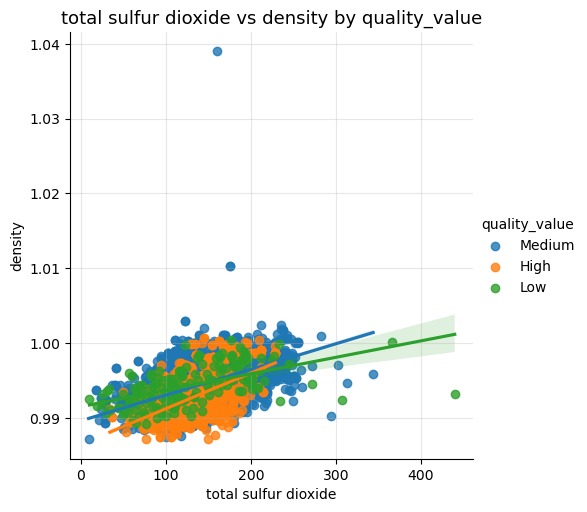

total sulfur dioxide vs pH Skipped, low Correlation
total sulfur dioxide vs sulphates Skipped, low Correlation

Distrubiton of total sulfur dioxide vs alcohol over the target (quality_value)



<Figure size 1000x600 with 0 Axes>

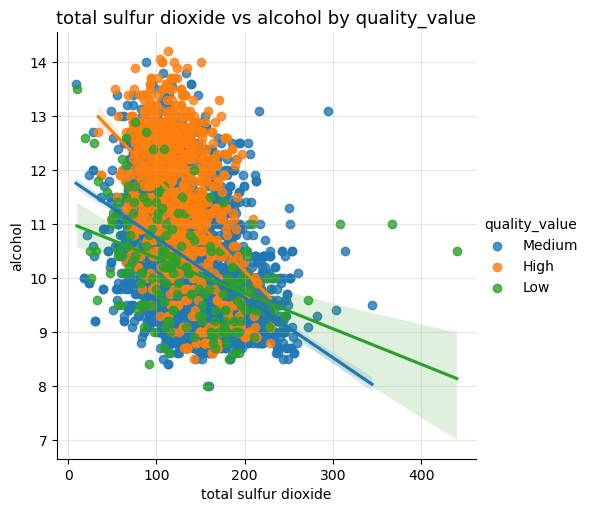

total sulfur dioxide vs quality Skipped, low Correlation
density vs pH Skipped, low Correlation
density vs sulphates Skipped, low Correlation

Distrubiton of density vs alcohol over the target (quality_value)



<Figure size 1000x600 with 0 Axes>

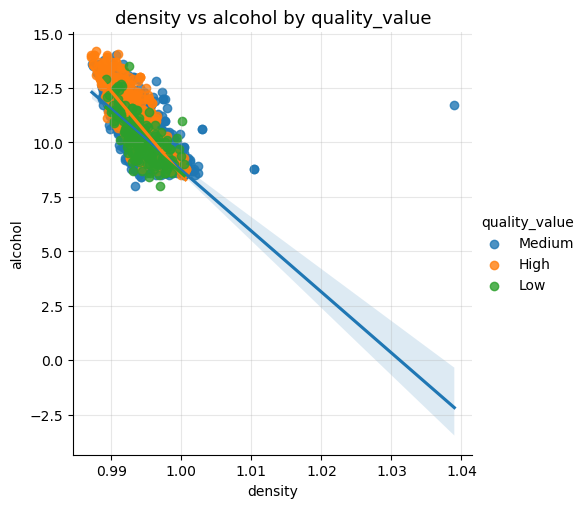


Distrubiton of density vs quality over the target (quality_value)



<Figure size 1000x600 with 0 Axes>

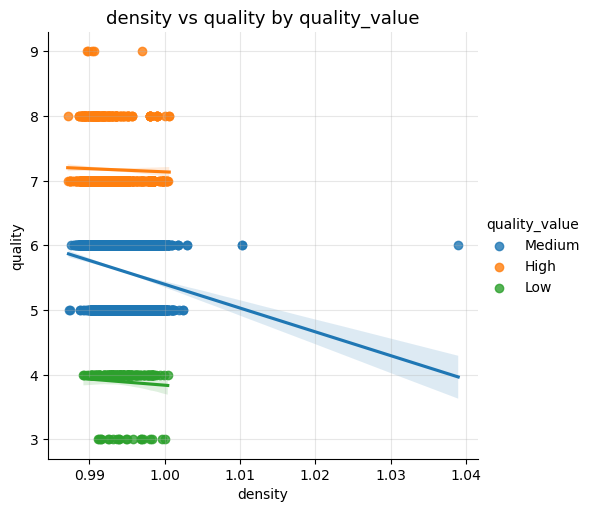

pH vs sulphates Skipped, low Correlation
pH vs alcohol Skipped, low Correlation
pH vs quality Skipped, low Correlation
sulphates vs alcohol Skipped, low Correlation
sulphates vs quality Skipped, low Correlation

Distrubiton of alcohol vs quality over the target (quality_value)



<Figure size 1000x600 with 0 Axes>

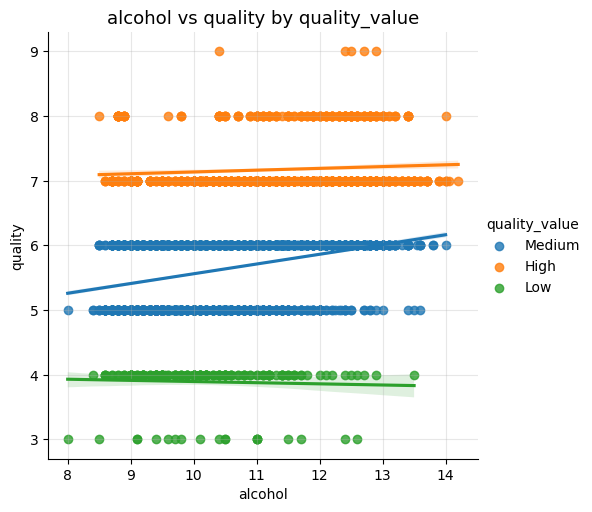

In [84]:
for f1,f2 in itertools.combinations(numeric_cols,2):
    trivarite(df,feature1=f1, feature2=f2, target="quality_value")

## Building Model

In [85]:
# importing sklearn libraries
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

In [86]:
# let drop the quality_value (category) we created then
df.drop(columns=["quality_value"], inplace=True)

In [87]:
# let define our x and y
y=df["quality"]
x=df.drop(columns=["quality"])

# let split our data

x_train, x_test, y_train, y_test = train_test_split(x,y, stratify=y, test_size=0.2, random_state=234)


In [88]:
# the model
model= LogisticRegression(solver="lbfgs",random_state=234,max_iter=1000)
model.fit(x_train,y_train)

c:\Users\OLASQUARE\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=234)

c:\Users\OLASQUARE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\OLASQUARE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\OLASQUARE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The Model Accuracy is: 0.51
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        33
           5       0.55      0.55      0.55       291
           6       0.49      0.71      0.58       440
           7       0.45      0.14      0.22       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.51       980
   macro avg       0.21      0.20      0.19       980
weighted avg       0.47      0.51      0.46       980



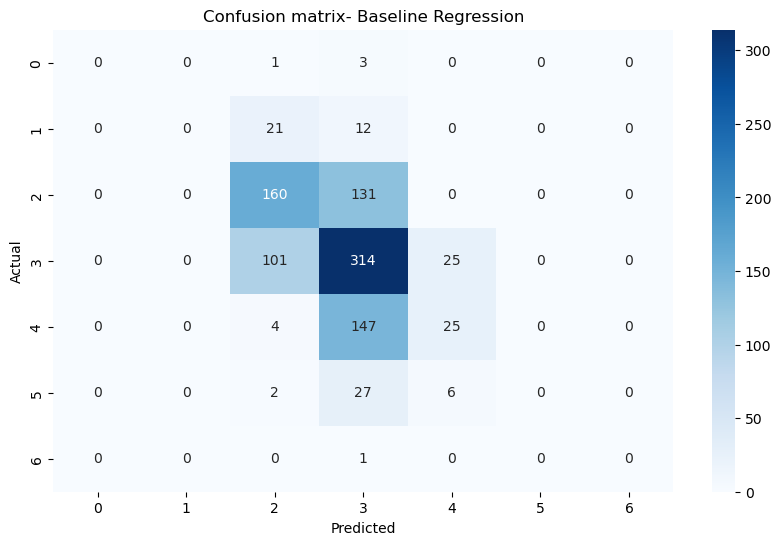

In [89]:
y_pred= model.predict(x_test)
report= classification_report(y_test, y_pred)
accuracy=accuracy_score(y_test, y_pred)
print(f"The Model Accuracy is: {accuracy:.2f}")
print(report)


# ploting the confussion matrix on map
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',cmap='Blues')
plt.title("Confusion matrix- Baseline Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [90]:
# let use tree base model
# set model
model= DecisionTreeClassifier(random_state=234)
model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=234)

In [91]:
# model predict
y_pred= model.predict(x_test)
report= classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.23      0.24      0.24        33
           5       0.63      0.64      0.64       291
           6       0.65      0.63      0.64       440
           7       0.57      0.60      0.58       176
           8       0.44      0.49      0.46        35
           9       0.00      0.00      0.00         1

    accuracy                           0.61       980
   macro avg       0.36      0.37      0.37       980
weighted avg       0.61      0.61      0.61       980



Baseline Decision Tree Accuracy: 0.61
Classification Report
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.23      0.24      0.24        33
           5       0.63      0.64      0.64       291
           6       0.65      0.63      0.64       440
           7       0.57      0.60      0.58       176
           8       0.44      0.49      0.46        35
           9       0.00      0.00      0.00         1

    accuracy                           0.61       980
   macro avg       0.36      0.37      0.37       980
weighted avg       0.61      0.61      0.61       980



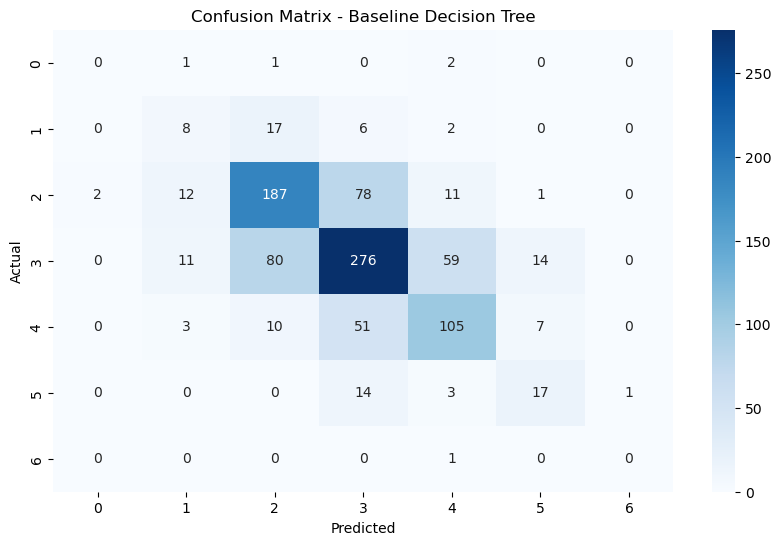

In [92]:
accuracy= accuracy_score(y_test, y_pred)
print(f"Baseline Decision Tree Accuracy: {accuracy:.2f}")
print(f"Classification Report\n {report}")

# plot heatmap of confusion matrix

plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap='Blues')
plt.title("Confusion Matrix - Baseline Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()